In [1]:
import pandas as pd

In [5]:
df = pd.read_csv("Articles.csv", encoding="latin1")

df.head()

,Article,Date,Heading,NewsType
0,KARACHI: The Sindh government has decided to b...,1/1/2015,sindh govt decides to cut public transport far...,business
1,HONG KONG: Asian markets started 2015 on an up...,1/2/2015,asia stocks up in new year trad,business
2,HONG KONG: Hong Kong shares opened 0.66 perce...,1/5/2015,hong kong stocks open 0.66 percent lower,business
3,HONG KONG: Asian markets tumbled Tuesday follo...,1/6/2015,asian stocks sink euro near nine year,business
4,NEW YORK: US oil prices Monday slipped below $...,1/6/2015,us oil prices slip below 50 a barr,business


In [6]:
print(df.columns)

Index(['Article', 'Date', 'Heading', 'NewsType'], dtype='object')


In [7]:
df['combined'] = df['Heading'].fillna("") + " " + df['Article'].fillna("")

In [10]:
df

,Article,Date,Heading,NewsType,combined
0,KARACHI: The Sindh government has decided to b...,1/1/2015,sindh govt decides to cut public transport far...,business,sindh govt decides to cut public transport far...
1,HONG KONG: Asian markets started 2015 on an up...,1/2/2015,asia stocks up in new year trad,business,asia stocks up in new year trad HONG KONG: Asi...
2,HONG KONG: Hong Kong shares opened 0.66 perce...,1/5/2015,hong kong stocks open 0.66 percent lower,business,hong kong stocks open 0.66 percent lower HONG ...
3,HONG KONG: Asian markets tumbled Tuesday follo...,1/6/2015,asian stocks sink euro near nine year,business,asian stocks sink euro near nine year HONG KO...
4,NEW YORK: US oil prices Monday slipped below $...,1/6/2015,us oil prices slip below 50 a barr,business,us oil prices slip below 50 a barr NEW YORK: U...
...,...,...,...,...,...
2687,strong>DUBAI: Dubai International Airport and ...,3/25/2017,Laptop ban hits Dubai for 11m weekend traveller,business,Laptop ban hits Dubai for 11m weekend travelle...
2688,"strong>BEIJING: Former Prime Minister, Shaukat...",3/26/2017,Pak China relations not against any third coun...,business,Pak China relations not against any third coun...
2689,strong>WASHINGTON: Uber has grounded its fleet...,3/26/2017,Uber grounds self driving cars after accid,business,Uber grounds self driving cars after accid str...
2690,strong>BEIJING: The New Development Bank plans...,3/27/2017,New Development Bank plans joint investments i...,business,New Development Bank plans joint investments i...


In [15]:
import nltk
import re
from nltk.corpus import stopwords
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [16]:
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = word_tokenize(text)
    return [w for w in tokens if w not in stop_words and len(w) > 2]

sentences = df['combined'].apply(preprocess).tolist()

In [17]:
print(sentences[0][:15])


['sindh', 'govt', 'decides', 'cut', 'public', 'transport', 'fares', 'kti', 'rej', 'karachi', 'sindh', 'government', 'decided', 'bring', 'public']


In [18]:
from gensim.models import Word2Vec

model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=3,
    workers=4
)

In [19]:
print("ai" in model.wv.key_to_index)
print("human" in model.wv.key_to_index)

False
True


In [31]:
print("Vocabulary size:", len(model.wv))

Vocabulary size: 12926


In [22]:
model.wv.index_to_key[:20]

['said',
 'pakistan',
 'percent',
 'year',
 'first',
 'strong',
 'oil',
 'world',
 'two',
 'last',
 'also',
 'new',
 'one',
 'england',
 'would',
 'prices',
 'three',
 'india',
 'test',
 'cricket']

In [23]:
model.wv.most_similar("government", topn=10)

[('gst', 0.940327525138855),
 ('budget', 0.9160463213920593),
 ('tax', 0.9158195853233337),
 ('approved', 0.9142425656318665),
 ('official', 0.9101797938346863),
 ('pml', 0.9062501192092896),
 ('revenue', 0.905805766582489),
 ('opic', 0.9037492275238037),
 ('exempted', 0.9027321338653564),
 ('broadening', 0.9010812640190125)]

In [24]:
model.wv.most_similar("technology", topn=10)

[('strategic', 0.9907342195510864),
 ('communication', 0.9859294891357422),
 ('businesses', 0.9849212169647217),
 ('law', 0.9846020340919495),
 ('erdogan', 0.9842084050178528),
 ('access', 0.9834546446800232),
 ('treaty', 0.9832051992416382),
 ('ambassador', 0.9830695390701294),
 ('jang', 0.9830151200294495),
 ('corporate', 0.982662558555603)]

In [25]:
model.wv.similarity("government", "govt")

np.float32(0.6371803)

In [26]:
model.wv.similarity("public", "people")

np.float32(0.82335526)

In [28]:
model.save("news_word2vec.model")

In [30]:
from gensim.models import Word2Vec
model = Word2Vec.load("news_word2vec.model")

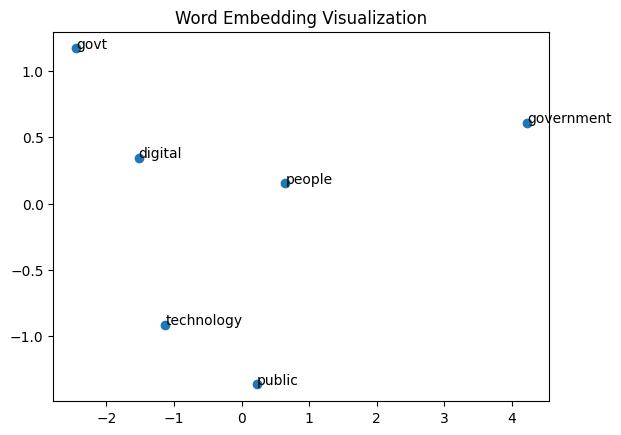

In [32]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

words = ["government", "govt", "public", "people", "technology", "digital"]
vectors = [model.wv[w] for w in words]

pca = PCA(n_components=2)
coords = pca.fit_transform(vectors)

plt.figure()
plt.scatter(coords[:,0], coords[:,1])

for word, (x, y) in zip(words, coords):
    plt.text(x, y, word)

plt.title("Word Embedding Visualization")
plt.show()
